In [ ]:
import torch
from diffusers import StableDiffusion3Pipeline
from huggingface_hub import login
# Import the userdata module from colab
from google.colab import userdata


# Safely pull the secret from Colab
login(token=hf_token)

DEVICE = "cuda"
DTYPE = torch.float16

pipe = StableDiffusion3Pipeline.from_pretrained(
    "stabilityai/stable-diffusion-3-medium-diffusers",
    torch_dtype=DTYPE,
).to(DEVICE)


In [ ]:
# ── CONFIG ─────────────────────────────────────────────────────────────
CONCEPT_PROMPT  = "a bed"               # what to steer away from
NEUTRAL_PROMPT  = "an empty room"              # neutral baseline
GEN_PROMPT      = "a bed in a room"     # prompt used at generation time

# Best known working pair: CLIP-L=10, T5=2 (Exp #17)
ALPHAS_C = [0, 2, 4, 6, 8, 10]         # CLIP-L alpha sweep
ALPHAS_T = [2]                          # T5 alpha (best: 2)
ALPHAS_G = [0]                          # CLIP-G alpha (not needed for object steering)
NUM_STEPS       = 28
GUIDANCE_SCALE  = 7.0
SEED            = 42
# ────────────────────────────────────────────────────────────────────────

In [17]:
def clear_all_hooks():
    pipe.transformer.time_text_embed._forward_hooks.clear()
    pipe.transformer.time_text_embed._forward_pre_hooks.clear()
    pipe.transformer.context_embedder._forward_hooks.clear()
    pipe.transformer.context_embedder._forward_pre_hooks.clear()
    for blk in pipe.transformer.transformer_blocks:
        blk._forward_hooks.clear()
        blk._forward_pre_hooks.clear()
clear_all_hooks()

def masked_mean(act, prompt, tokenizer, max_length):
    tok  = tokenizer(prompt, return_tensors="pt", padding="max_length",
                     max_length=max_length, truncation=True)
    mask = tok.attention_mask[0].bool()
    return act[mask].mean(dim=0)

# ── Capture per-step context embeddings + pooled embedding ───────────────
def capture(prompt):
    ctx_steps = {}
    pooled_cache = {}
    counter = [0]

    def _ctx_hook(module, inp, out):
        ctx_steps[counter[0]] = out[1].detach().float()
        counter[0] += 1

    def _pooled_pre_hook(module, args):
        if "pooled" not in pooled_cache:
            pooled_cache["pooled"] = args[1][1].detach().float()  # (2048,)

    h1 = pipe.transformer.context_embedder.register_forward_hook(_ctx_hook)
    h2 = pipe.transformer.time_text_embed.register_forward_pre_hook(_pooled_pre_hook)
    with torch.no_grad():
        pipe(prompt, num_inference_steps=NUM_STEPS, output_type="latent",
             generator=torch.Generator(DEVICE).manual_seed(0))
    h1.remove()
    h2.remove()
    return ctx_steps, pooled_cache["pooled"]

print("Capturing concept activations...")
concept_ctx_steps, concept_pooled = capture(CONCEPT_PROMPT)
print("Capturing neutral activations...")
neutral_ctx_steps, neutral_pooled = capture(NEUTRAL_PROMPT)

# ── Per-step CLIP-L and T5 directions ────────────────────────────────────
dir_clip_steps = {}
dir_t5_steps   = {}
for step in range(NUM_STEPS):
    diff = concept_ctx_steps[step] - neutral_ctx_steps[step]
    d = masked_mean(diff[:77], CONCEPT_PROMPT, pipe.tokenizer, 77)
    dir_clip_steps[step] = (d / (d.norm() + 1e-8)).to(DEVICE, dtype=DTYPE)
    if pipe.tokenizer_3 is not None:
        d = masked_mean(diff[77:], CONCEPT_PROMPT, pipe.tokenizer_3, 256)
        dir_t5_steps[step] = (d / (d.norm() + 1e-8)).to(DEVICE, dtype=DTYPE)

# ── CLIP-G pooled direction (positions 768:2048) ──────────────────────────
clipg_diff = concept_pooled[768:] - neutral_pooled[768:]  # (1280,)
dir_clipg   = (clipg_diff / (clipg_diff.norm() + 1e-8)).to(DEVICE, dtype=DTYPE)

print(f"Per-step dirs: {len(dir_clip_steps)} CLIP-L, {len(dir_t5_steps)} T5")
print(f"CLIP-G pooled direction norm: {dir_clipg.norm().item():.4f}")

Capturing concept activations...


  0%|          | 0/10 [00:00<?, ?it/s]

Capturing neutral activations...


  0%|          | 0/10 [00:00<?, ?it/s]

Per-step dirs: 10 CLIP-L, 10 T5
CLIP-G pooled direction norm: 1.0000


In [ ]:
# To generate baseline image
clear_all_hooks()

with torch.no_grad():
    baseline = pipe(
        GEN_PROMPT,
        guidance_scale=GUIDANCE_SCALE,
        num_inference_steps=NUM_STEPS,
        generator=torch.Generator(DEVICE).manual_seed(SEED),
    ).images[0]

clear_all_hooks()
# display(baseline)
# baseline.save("baseline.png")

  0%|          | 0/10 [00:00<?, ?it/s]

c=0 t=2 g=0: ok (mean=170.0)


  0%|          | 0/10 [00:00<?, ?it/s]

c=2 t=2 g=0: ok (mean=159.1)


  0%|          | 0/10 [00:00<?, ?it/s]

...

c=6 t=2 g=0: ok (mean=137.5)


  0%|          | 0/10 [00:00<?, ?it/s]

c=8 t=2 g=0: ok (mean=145.4)


  0%|          | 0/10 [00:00<?, ?it/s]

c=10 t=2 g=0: ok (mean=153.1)


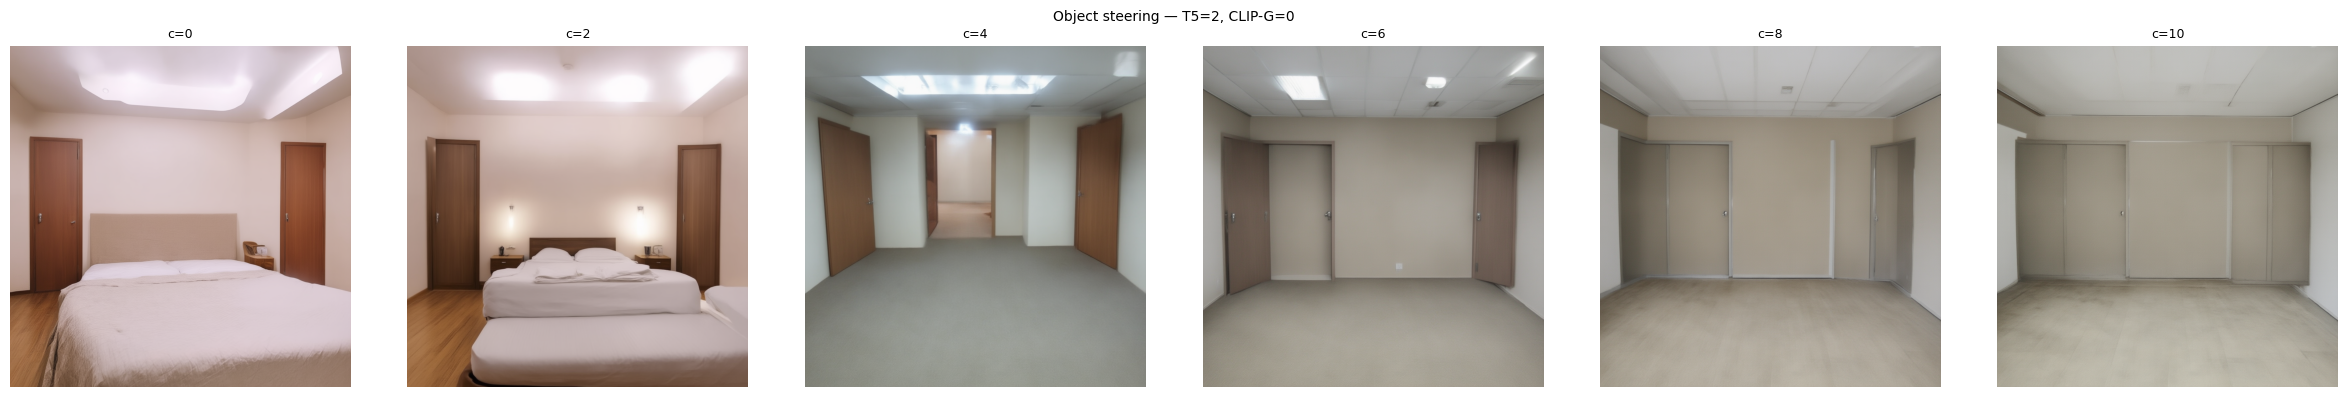

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

def make_placeholder(label):
    img = Image.new('RGB', (512, 512), (40, 40, 40))
    ImageDraw.Draw(img).text((180, 240), f"{label}\nNaN/OOB", fill=(255, 80, 80))
    return img

def run(a_clip, a_t5, a_clipg):
    counter = [0]
    def _ctx_hook(module, inp, out, _ac=a_clip, _at=a_t5):
        step = counter[0] % NUM_STEPS
        counter[0] += 1
        out_f = out.clone().float()
        d = dir_clip_steps[step].float()
        proj = torch.clamp(out_f[:, :77, :] @ d, min=0.0).unsqueeze(-1)
        out_f[:, :77, :] -= _ac * proj * d
        if step in dir_t5_steps:
            d = dir_t5_steps[step].float()
            proj = torch.clamp(out_f[:, 77:, :] @ d, min=0.0).unsqueeze(-1)
            out_f[:, 77:, :] -= _at * proj * d
        return out_f.to(out.dtype)
    def _pooled_pre_hook(module, args, _ag=a_clipg):
        timestep, pooled = args
        pooled_f = pooled.clone().float()
        d = dir_clipg.float()
        proj = (pooled_f[:, 768:] @ d).unsqueeze(-1)
        pooled_f[:, 768:] -= _ag * proj * d
        return (timestep, pooled_f.to(pooled.dtype))
    h1 = pipe.transformer.context_embedder.register_forward_hook(_ctx_hook)
    h2 = pipe.transformer.time_text_embed.register_forward_pre_hook(_pooled_pre_hook)
    try:
        with torch.no_grad():
            img = pipe(GEN_PROMPT, guidance_scale=GUIDANCE_SCALE,
                       num_inference_steps=NUM_STEPS,
                       generator=torch.Generator(DEVICE).manual_seed(SEED)).images[0]
        arr = np.array(img)
        if arr.mean() > 250 or arr.mean() < 5:
            img = make_placeholder(f"c={a_clip} t={a_t5} g={a_clipg}")
            print(f"c={a_clip} t={a_t5} g={a_clipg}: degenerate")
        else:
            print(f"c={a_clip} t={a_t5} g={a_clipg}: ok (mean={arr.mean():.1f})")
    except Exception as e:
        img = make_placeholder(f"c={a_clip} t={a_t5} g={a_clipg}")
        print(f"error: {e}")
    finally:
        h1.remove(); h2.remove()
    return img

# Sweep CLIP-L alpha; T5 fixed at ALPHAS_T[0]; CLIP-G fixed at ALPHAS_G[0]
a_t5   = ALPHAS_T[0]
a_clipg = ALPHAS_G[0]
sweep_imgs = [run(a_clip, a_t5, a_clipg) for a_clip in ALPHAS_C]

labels = [f"c={a}" for a in ALPHAS_C]
fig, axes = plt.subplots(1, len(ALPHAS_C), figsize=(4 * len(ALPHAS_C), 4))
for ax, label, img in zip(axes, labels, sweep_imgs):
    ax.imshow(img); ax.set_title(label, fontsize=9); ax.axis("off")
plt.suptitle(f"Object steering — T5={a_t5}, CLIP-G={a_clipg}", fontsize=10)
plt.tight_layout()
plt.show()